In [1]:
# R Environment (must be set BEFORE importing rpy2)
import os
os.environ['R_HOME'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R'
os.environ['R_LIBS'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'
os.environ['R_LIBS_USER'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'

# Python Packages
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print(f"\nscanpy: {sc.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print("✓ Python packages loaded")

# rpy2 Setup
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
print(f"\n✓ rpy2 loaded | {ro.r('R.version$version.string')[0]}")

ro.r('suppressPackageStartupMessages(library(lme4))')
lme4_ver = ro.r('as.character(packageVersion("lme4"))')[0]
print(f"✓ R packages: lme4 {lme4_ver}")

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]



scanpy: 1.11.5
numpy: 2.2.6
pandas: 2.3.3
✓ Python packages loaded

✓ rpy2 loaded | R version 4.5.1 (2025-06-13)


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package ‘lme4’ was built under R version 4.5.2 
  


✓ R packages: lme4 1.1.38


In [2]:
import matplotlib.pyplot as plt

try:
    import scanpy as sc
    sc.settings.verbosity = 1
    sc.settings.set_figure_params(dpi=150, dpi_save=300, facecolor='white', frameon=False)
except ImportError:
    pass

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

SEX_COLORS = {'Male': '#5D6D7E', 'Female': '#A569BD'}

STUDY_GROUP_COLORS = {
    'Age_20_29': '#2E86AB', 'Age_30_39': '#4A90E2', 'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347', 'Age_60_69': '#FF8C00', 'Age_70_79': '#E24A4A',
    'Age_80_100': '#8B0000',
    'Control': '#4E79A7', 'MCI': '#F28E2B', 'AD': '#E15759', 'NCI': '#4E79A7',
    'Young_Healthy_Control': '#4E79A7', 'Old_Healthy_Control': '#59A14F',
    'Old_AD': '#E15759',
}

STUDY_GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
                     'Age_60_69', 'Age_70_79', 'Age_80_100']

COHORT_COLORS = {'MSSM': '#2E86AB', 'HBCC': '#E24A4A', 'RUSH': '#50C878',
                 'PsychAD': '#2E86AB', 'PsychENCODE': '#E24A4A',
                 'ROSMAP': '#50C878', 'Mathys': '#FFB347'}

CELL_TYPE_COLORS = {
    'EN': '#0072B2', 'Excitatory': '#0072B2', 'excitatory': '#0072B2',
    'IN': '#E69F00', 'Inhibitory': '#E69F00', 'inhibitory': '#E69F00',
    'Astro': '#009E73', 'Astrocyte': '#009E73', 'Astrocytes': '#009E73',
    'Oligo': '#56B4E9', 'Oligodendrocyte': '#56B4E9', 'Oligodendrocytes': '#56B4E9',
    'OPC': '#CC79A7', 'OPCs': '#CC79A7',
    'Micro': '#D55E00', 'Microglia': '#D55E00',
    'Endo': '#7F7F7F', 'Endothelial': '#7F7F7F',
    'Vascular': '#7F7F7F', 'vascular': '#7F7F7F',
    'PVM': '#D37295', 'Pericyte': '#999999', 'Mural': '#999999',
    'VSMC': '#9C755F', 'VLMC': '#BAB0AC', 'OVM': '#9C755F',
    'Adaptive': '#FABFD2', 'Immune': '#B6992D', 'immune': '#B6992D',
}

SEX_COLORS = {'Male': '#5D6D7E', 'Female': '#A569BD',
              'male': '#5D6D7E', 'female': '#A569BD',
              'M': '#5D6D7E', 'F': '#A569BD',
              'm': '#5D6D7E', 'f': '#A569BD',
              '0': '#5D6D7E', '1': '#A569BD', 0: '#5D6D7E', 1: '#A569BD'}

PALETTES = {'sex': SEX_COLORS, 'study_group': STUDY_GROUP_COLORS,
            'cohort': COHORT_COLORS, 'cell_type': CELL_TYPE_COLORS}

COHORT_COLORS['PsychEncode'] = '#67000D'
COHORT_COLORS['PsychAD'] = '#08306B'
COHORT_COLORS['Mathys']  = '#67000D'
PALETTES['cohort'] = COHORT_COLORS

def color_for(variable, levels, missing='#808080'):
    pal = PALETTES[variable]
    out = [pal.get(str(lv), missing) for lv in levels]
    gaps = [str(lv) for lv, c in zip(levels, out) if c == missing]
    if gaps:
        print(f"WARNING: no {variable} color for {sorted(set(gaps))}, using grey")
    return out

print("✓ Figure settings and palettes configured")

✓ Figure settings and palettes configured


# Figure 1C

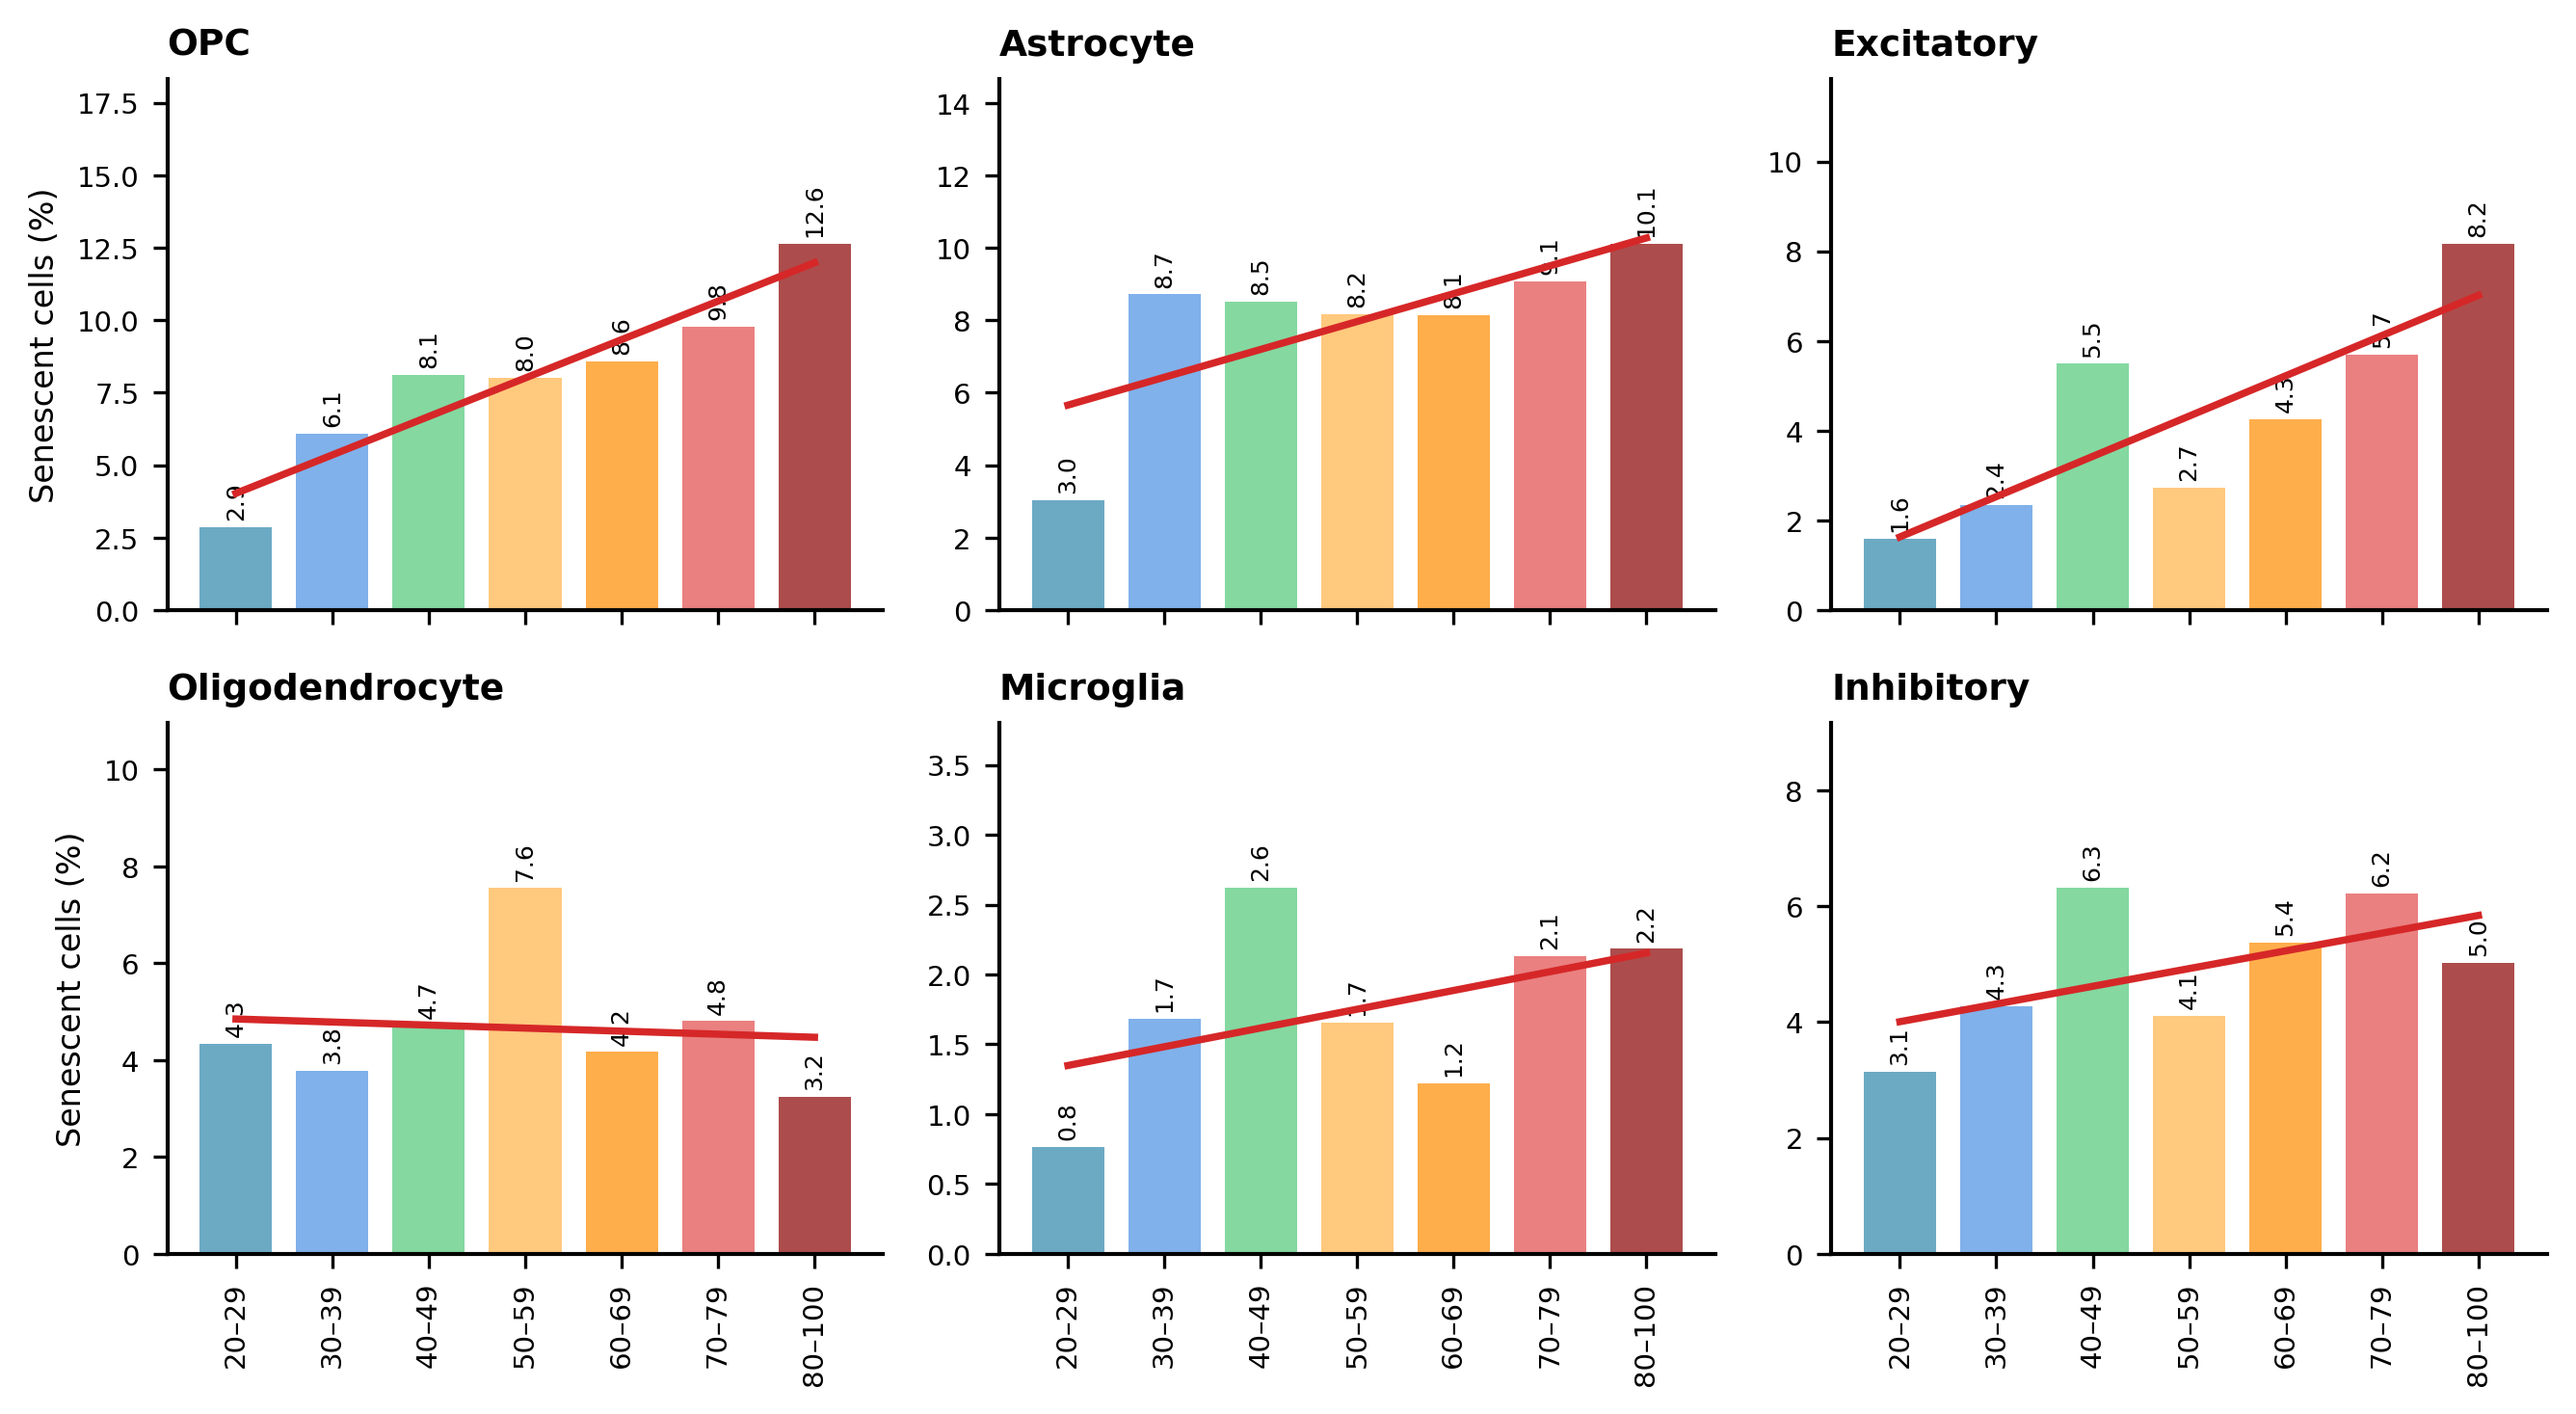

In [3]:
CELL_TYPES = ['OPC', 'Astrocyte', 'Excitatory', 'Oligodendrocyte', 'Microglia', 'Inhibitory']
NROW, NCOL = 2, 3

import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv('results/fig1C_source_data.csv')

c = (df[(df.panel == 'Fig1C') & (df.metric == 'pct_senescent')]
       .pivot(index='study_group', columns='stratum', values='value'))
c = c.reindex([g for g in STUDY_GROUP_ORDER if g in c.index])

fits = (df[df.panel == 'Fig1C_fit']
          .pivot(index='stratum', columns='metric', values='value'))

groups = list(c.index)
labels = [g.replace('Age_', '').replace('_', '–') for g in groups]
x = np.arange(len(groups))

types = [t for t in CELL_TYPES if t in c.columns]
fig, axes = plt.subplots(NROW, NCOL, figsize=(3.0 * NCOL, 2.5 * NROW), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, ct in zip(axes, types):
    y = c[ct].values
    bars = ax.bar(x, y, width=0.75, color=color_for('study_group', groups),
                  alpha=0.7, edgecolor='none')

    for bar, pct in zip(bars, y):
        if pct > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y.max()*0.02,
                    f'{pct:.1f}', ha='center', va='bottom', fontsize=6, rotation=90)

    if ct in fits.index:
        f = fits.loc[ct]
        ax.plot(x, f['line_intercept'] + f['line_slope_per_step'] * x,
                color='#D62728', lw=1.8, zorder=3)

    ax.set_title(ct, fontsize=9, fontweight='bold', loc='left')
    ax.set_ylim(0, max(y) * 1.45)
    ax.tick_params(labelsize=7)

for ax in axes[len(types):]:
    ax.set_visible(False)
for ax in axes[:len(types)]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
for i, ax in enumerate(axes[:len(types)]):
    if i % NCOL == 0:
        ax.set_ylabel('Senescent cells (%)', fontsize=8)

fig.tight_layout()
plt.show()

# Figure 1D

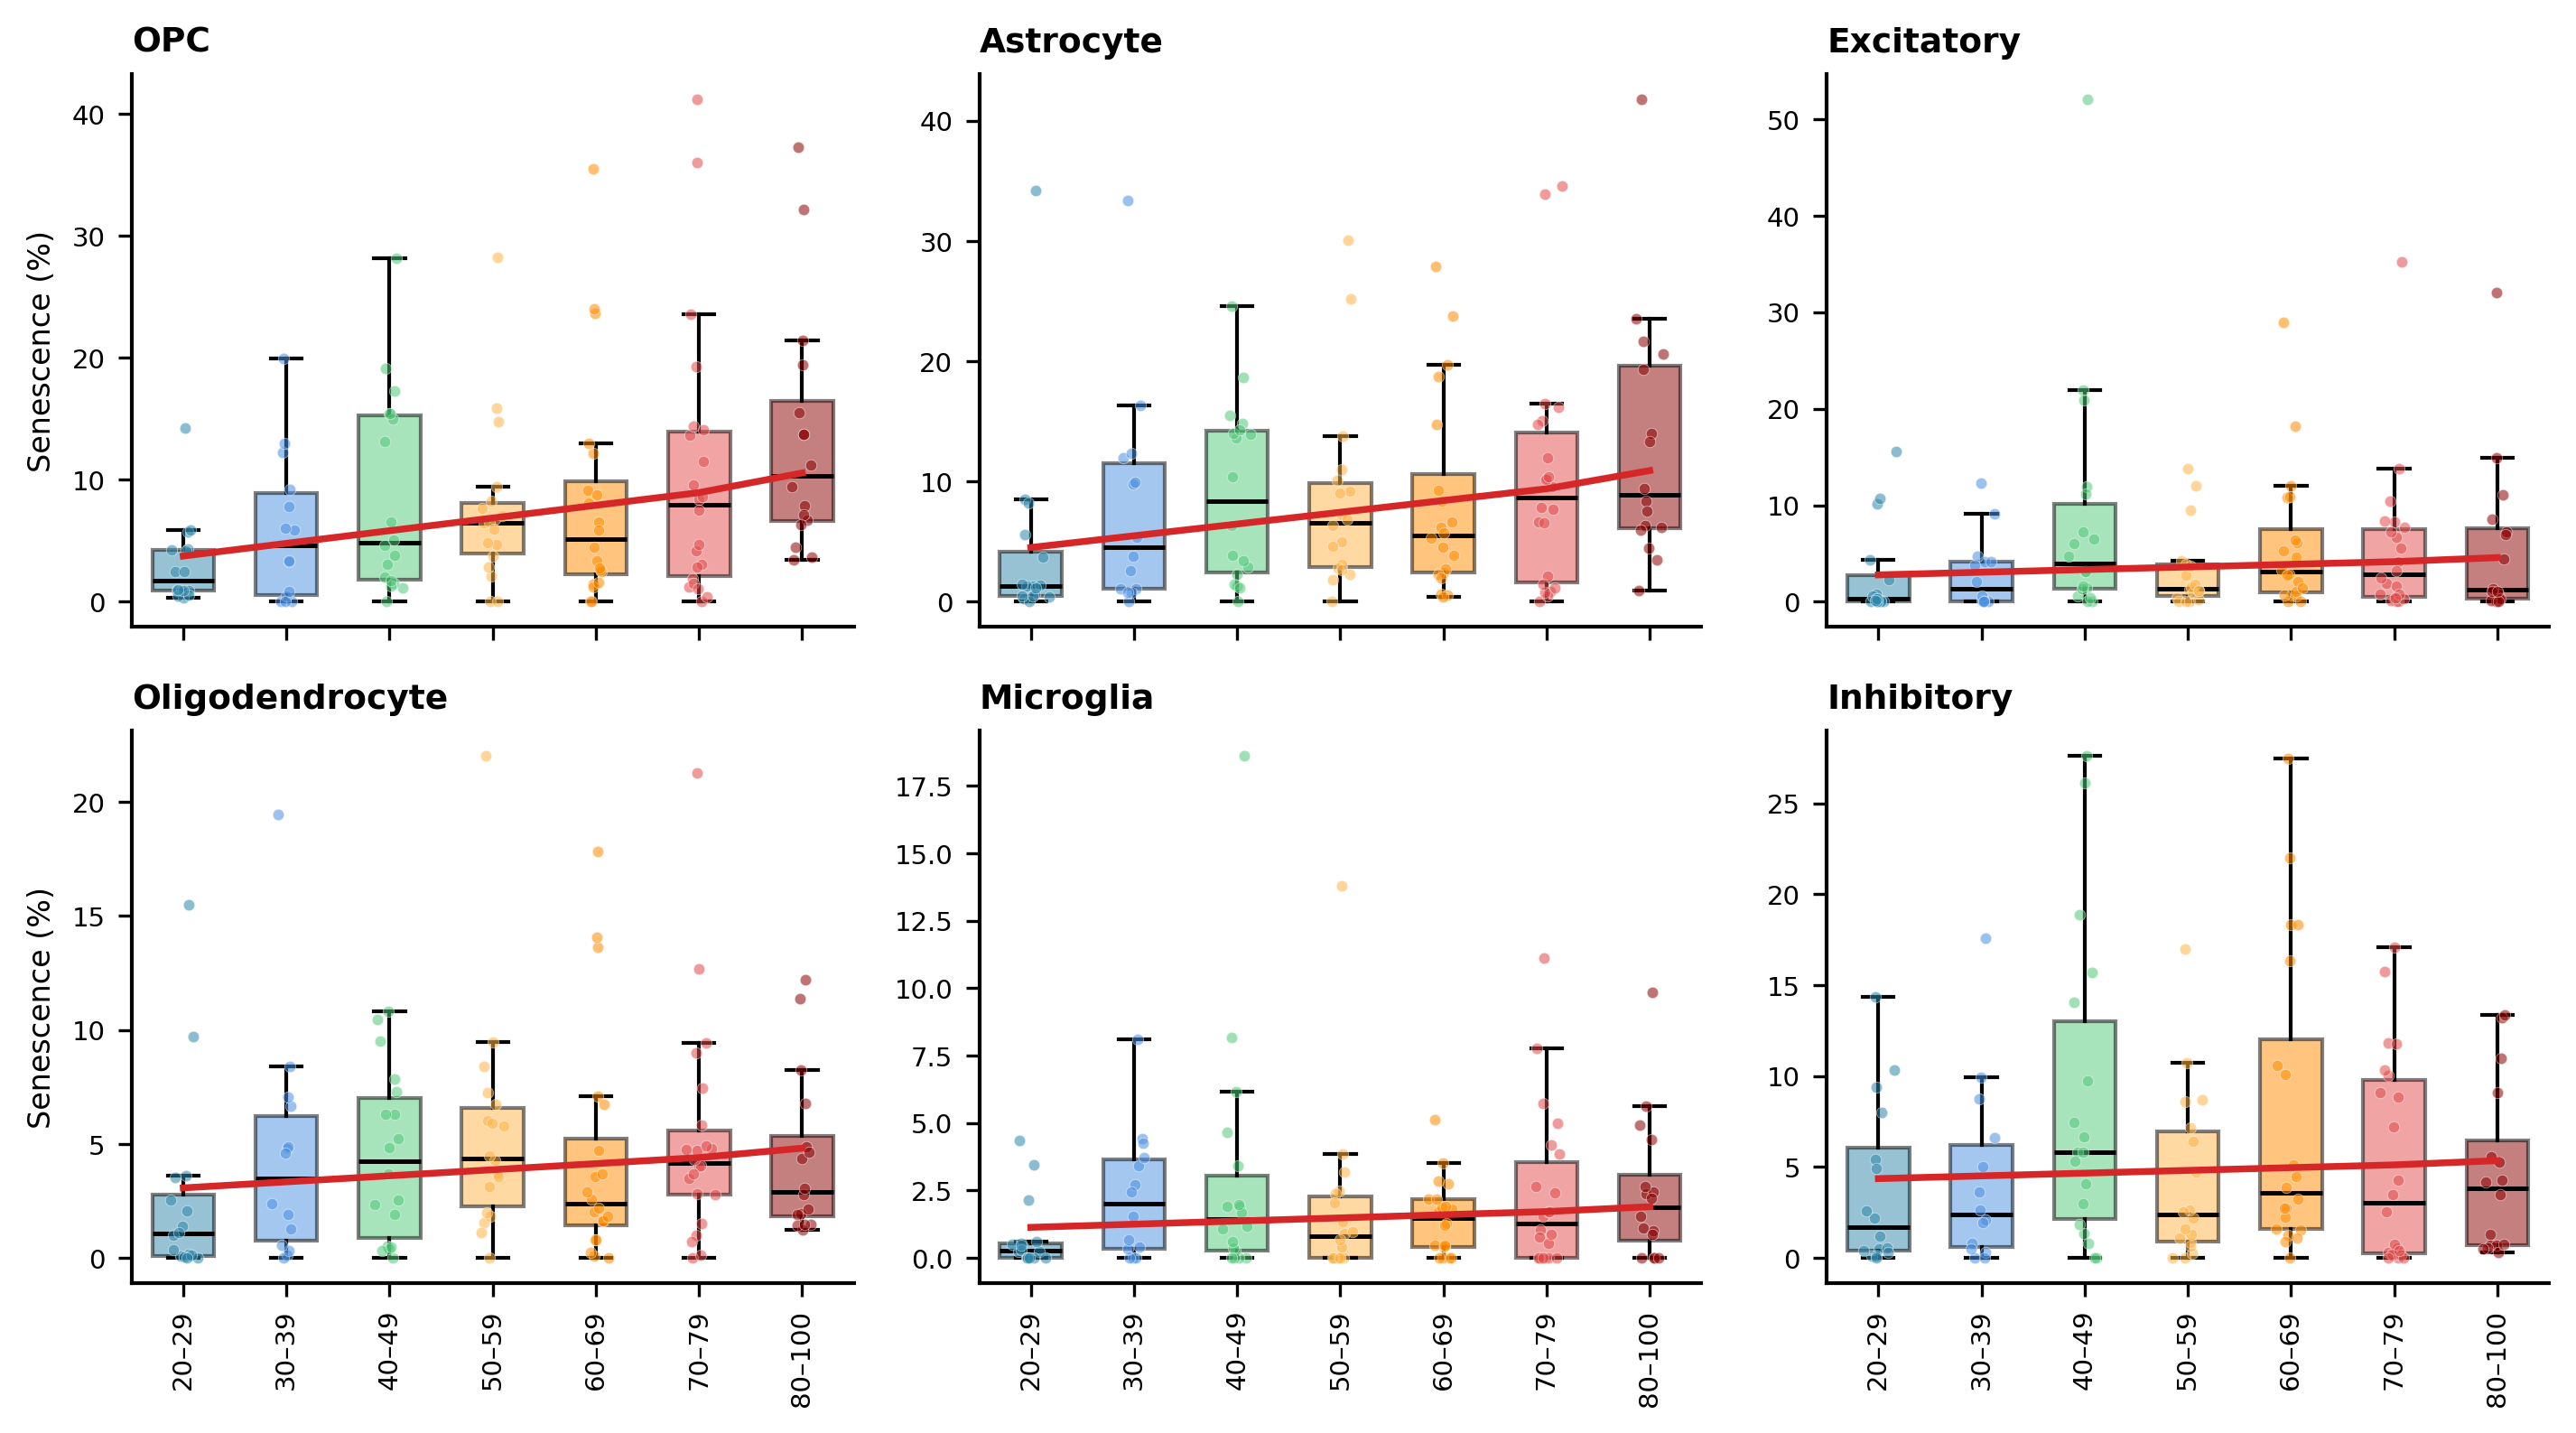

In [4]:
CELL_TYPES = ['OPC', 'Astrocyte', 'Excitatory', 'Oligodendrocyte', 'Microglia', 'Inhibitory']
NROW, NCOL  = 2, 3
JITTER_SEED = 42

df = pd.read_csv('results/fig1D_source_data.csv')

box  = df[df.panel == 'Fig1D']
pts  = df[df.panel == 'Fig1D_pts']
fits = df[df.panel == 'Fig1D_fit'].pivot(index='stratum', columns='metric', values='value')

groups = [g for g in STUDY_GROUP_ORDER if g in set(box.study_group)]
labels = [g.replace('Age_', '').replace('_', '–') for g in groups]
mid = np.array([np.mean([float(p) for p in g.replace('Age_', '').split('_')])
                for g in groups])
colors = color_for('study_group', groups)

types = [t for t in CELL_TYPES if t in set(box.stratum)]
fig, axes = plt.subplots(NROW, NCOL, figsize=(3.2 * NCOL, 2.7 * NROW), sharex=True)
axes = np.atleast_1d(axes).ravel()
rng = np.random.default_rng(JITTER_SEED)

for ax, ct in zip(axes, types):
    b = (box[box.stratum == ct]
           .pivot(index='study_group', columns='metric', values='value')
           .reindex(groups))

    stats = [{'label': lab, 'med': r['median'], 'q1': r['q1'], 'q3': r['q3'],
              'whislo': r['whislo'], 'whishi': r['whishi'], 'fliers': []}
             for lab, (_, r) in zip(labels, b.iterrows())]

    bp = ax.bxp(stats, patch_artist=True, showfliers=False, widths=0.6,
                medianprops=dict(color='black', linewidth=1.2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    p = pts[pts.stratum == ct]
    for j, g in enumerate(groups):
        v = p.loc[p.study_group == g, 'value'].values
        if len(v):
            ax.scatter(rng.normal(j + 1, 0.06, len(v)), v, s=9, alpha=0.55,
                       color=colors[j], edgecolors='white', linewidth=0.2, zorder=3)

    if ct in fits.index:
        f = fits.loc[ct]
        ax.plot(np.arange(1, len(groups) + 1),
                f['line_intercept_pct'] + f['line_slope_pct'] * (mid / 10.0),
                color='#D62728', lw=1.8, zorder=4)

    ax.set_title(ct, fontsize=9, fontweight='bold', loc='left')
    ax.tick_params(labelsize=7)

for ax in axes[len(types):]:
    ax.set_visible(False)
for ax in axes[:len(types)]:
    ax.set_xticks(np.arange(1, len(groups) + 1))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
for i, ax in enumerate(axes[:len(types)]):
    if i % NCOL == 0:
        ax.set_ylabel('Senescence (%)', fontsize=8)

fig.tight_layout()
plt.show()

# Figure 1E

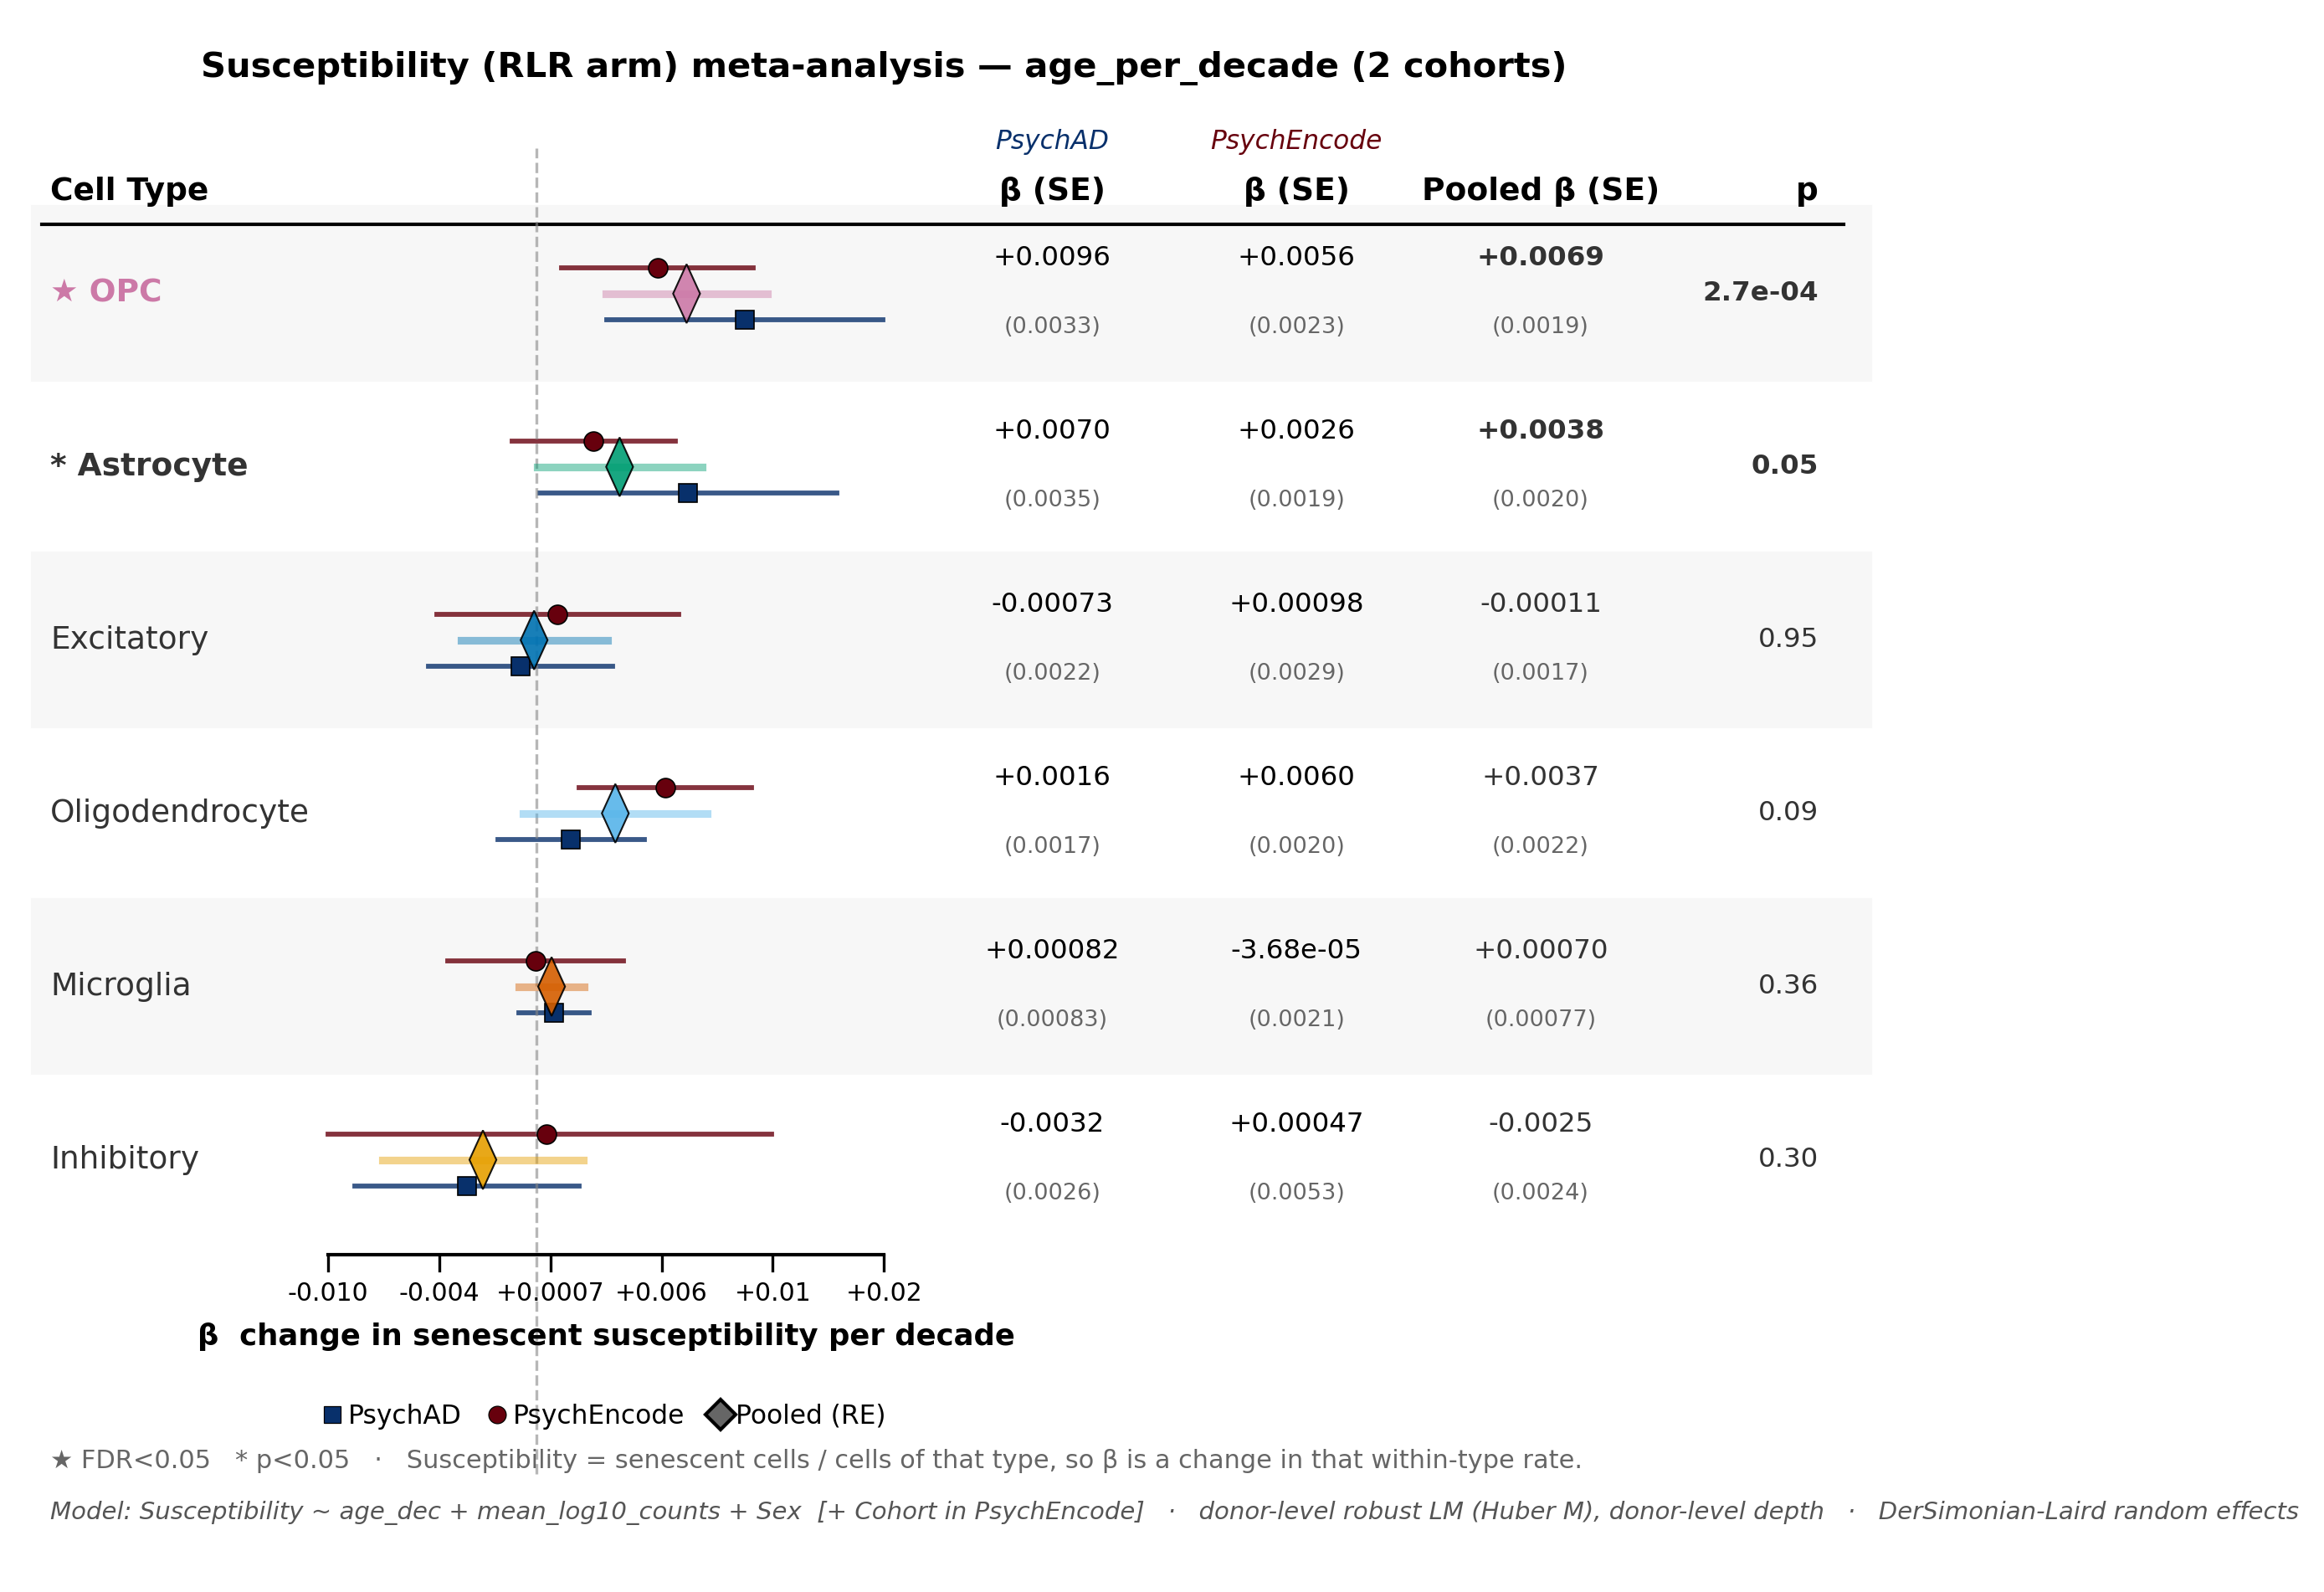

In [5]:
META_PATH = 'results/fig1E_source_data.csv'

ARM = dict(
    title="Susceptibility (RLR arm)",
    xlabel="β  change in senescent susceptibility per decade",
    formula="Susceptibility ~ age_dec + mean_log10_counts + Sex  [+ Cohort in PsychEncode]",
    method="donor-level robust LM (Huber M), donor-level depth",
    note="Susceptibility = senescent cells / cells of that type, so β is a change "
         "in that within-type rate.",
)
CONTRAST  = "age_per_decade"
FDR_LEVEL = 0.05
MAJOR_CTS = ["OPC", "Astrocyte", "Excitatory",
             "Oligodendrocyte", "Microglia", "Inhibitory"]
COHORT_MARK = {"PsychAD": "s", "PsychEncode": "o", "PsychENCODE": "o", "Mathys": "o"}

import ast, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

def fmt_b(v):
    a = abs(v)
    if a == 0:   return " 0"
    if a < 1e-4: return f"{v:+.2e}"
    if a < 1e-3: return f"{v:+.5f}"
    return f"{v:+.4f}"

def fmt_se(v):
    return f"({v:.2e})" if abs(v) < 1e-4 else f"({v:.5f})" if abs(v) < 1e-3 else f"({v:.4f})"

def fmt_tick(v):
    a = abs(v)
    if a < 1e-9: return "0"
    if a < 1e-3: return f"{v:+.4f}"
    if a < 1e-2: return f"{v:+.3f}"
    return f"{v:+.2f}"

def fmt_p(v):
    return f"{v:.1e}" if v < 0.001 else (f"{v:.3f}" if v < 0.01 else f"{v:.2f}")

meta = pd.read_csv(META_PATH)
as_list = lambda v: v if isinstance(v, (list, tuple, np.ndarray)) else ast.literal_eval(str(v))
for c in ("cohort_names", "cohort_betas", "cohort_ses"):
    meta[c] = meta[c].map(as_list)
if 'pooled_se' not in meta.columns:
    meta['pooled_se'] = (meta.ci_hi - meta.ci_lo) / (2 * 1.96)
meta = meta[meta.Cell_Type.isin(MAJOR_CTS)]
meta = (meta.assign(_o=meta.Cell_Type.map({c: i for i, c in enumerate(MAJOR_CTS)}))
            .sort_values("_o").drop(columns="_o").reset_index(drop=True))

names = list(dict.fromkeys(n for r in meta.cohort_names for n in r))
n = len(meta)

x = {"ct": 0.005, "fL": 0.17, "fR": 0.50}
for i, nm in enumerate(names): x[nm] = 0.60 + i * 0.145
b0 = 0.60 + len(names) * 0.145
cols = [("pooled", b0, "center"), ("p", b0 + 0.165, "right")]
x.update({k: v for k, v, _ in cols})
heads = {"pooled": "Pooled β (SE)", "p": "p"}

vals = [v for _, r in meta.iterrows() for v in list(r.cohort_betas) + [r.pooled_beta]]
lo, hi = min(vals), max(vals)
pad = max((hi - lo) * 0.5, 1e-7); lo, hi = lo - pad, hi + pad
to_x = lambda v: x["fL"] + (np.clip(v, lo, hi) - lo) / (hi - lo) * (x["fR"] - x["fL"])
off = [-0.15, 0.15] if len(names) == 2 else list(np.linspace(-0.18, 0.18, len(names)))

fig = plt.figure(figsize=(9.4, max(3.4, n * 0.64 + 2.6)))
ax = fig.add_subplot(111)
y_hdr, y_lbl = n - 0.5, n - 0.2

for nm in names:
    ax.text(x[nm], y_lbl, nm, fontsize=7.5, style="italic",
            color=color_for('cohort', [nm])[0], ha="center", va="bottom")
    ax.text(x[nm], y_hdr, "β (SE)", fontsize=9, fontweight="bold",
            ha="center", va="bottom")
ax.text(x["ct"], y_hdr, "Cell Type", fontsize=9, fontweight="bold", ha="left", va="bottom")
for key, xx, align in cols:
    ax.text(xx, y_hdr, heads[key], fontsize=9, fontweight="bold", ha=align, va="bottom")
ax.plot([0, 1.07], [y_hdr - 0.10, y_hdr - 0.10], "k-", lw=1, clip_on=False)

for i, r in meta.iterrows():
    yy = n - i - 1
    if i % 2 == 0:
        ax.axhspan(yy - 0.5, yy + 0.5, xmin=0.004, xmax=0.996, color="#f7f7f7", zorder=0)
    c = color_for('cell_type', [r.Cell_Type])[0]
    sig, sigp = bool(r.Significant), r.p < 0.05
    ax.text(x["ct"], yy, ("★ " if sig else "* " if sigp else "") + r.Cell_Type,
            fontsize=9, fontweight="bold" if sigp else "normal",
            ha="left", va="center", color=c if sig else "#333")

    for j, (nm, bb, se) in enumerate(zip(r.cohort_names, r.cohort_betas, r.cohort_ses)):
        yo = yy + off[j]; cc = color_for('cohort', [nm])[0]
        ax.plot([to_x(bb - 1.96 * se), to_x(bb + 1.96 * se)], [yo, yo],
                color=cc, lw=1.4, alpha=0.8, zorder=2)
        ax.plot(to_x(bb), yo, COHORT_MARK.get(nm, "o"), ms=5.5,
                color=cc, mec="black", mew=0.4, zorder=3)
        ax.text(x[nm], yy + 0.13, fmt_b(bb), fontsize=7.8, ha="center", va="bottom")
        ax.text(x[nm], yy - 0.13, fmt_se(se), fontsize=6.5, ha="center",
                va="top", color="#666")

    xr = to_x(r.pooled_beta)
    ax.plot([to_x(r.ci_lo), to_x(r.ci_hi)], [yy, yy], color=c, lw=2.2, alpha=0.45, zorder=4)
    ax.add_patch(Polygon([[xr - 0.008, yy], [xr, yy - 0.17], [xr + 0.008, yy],
                          [xr, yy + 0.17]], fc=c, ec="black", lw=0.5, zorder=5, alpha=0.9))

    cell = {"pooled": (fmt_b(r.pooled_beta), fmt_se(r.pooled_se)),
            "p": (fmt_p(r.p), None)}
    for key, xx, align in cols:
        top, bot = cell[key]
        fw = "bold" if sigp else "normal"
        ax.text(xx, yy + (0.13 if bot else 0), top, fontsize=7.8, ha=align,
                va="bottom" if bot else "center", fontweight=fw, color="#333")
        if bot:
            ax.text(xx, yy - 0.13, bot, fontsize=6.5, ha=align, va="top", color="#666")

ya = -0.55
ax.plot([x["fL"], x["fR"]], [ya, ya], "k-", lw=1)
ax.axvline(to_x(0), color="#888", ls="--", lw=0.8, ymin=0.06, ymax=0.92, alpha=0.6)
for t in np.linspace(lo, hi, 6):
    ax.plot([to_x(t)] * 2, [ya, ya - 0.09], "k-", lw=0.8)
    ax.text(to_x(t), ya - 0.15, fmt_tick(t), fontsize=7.2, ha="center", va="top")
ax.text((x["fL"] + x["fR"]) / 2, ya - 0.52, ARM["xlabel"],
        fontsize=8.5, fontweight="bold", ha="center")

leg = [Line2D([0], [0], marker=COHORT_MARK.get(nm, "o"), color="w",
              markerfacecolor=color_for('cohort', [nm])[0], markersize=5,
              markeredgecolor="black", markeredgewidth=0.3, label=nm) for nm in names]
leg.append(Line2D([0], [0], marker="D", color="w", markerfacecolor="#666",
                  markersize=6, markeredgecolor="black", label="Pooled (RE)"))
ax.legend(handles=leg, loc="upper center",
          bbox_to_anchor=((x["fL"] + x["fR"]) / 2, ya - 0.72),
          bbox_transform=ax.transData, fontsize=7.5, frameon=False,
          ncol=len(leg), handletextpad=0.35, columnspacing=1.1)

ax.text(0.5, y_lbl + 0.45,
        f"{ARM['title']} meta-analysis — {CONTRAST} ({len(names)} cohorts)",
        fontsize=10, fontweight="bold", ha="center")
ax.text(0.005, ya - 1.12,
        f"★ FDR<{FDR_LEVEL}   * p<0.05   ·   {ARM['note']}",
        fontsize=7.3, ha="left", va="top", color="#666")
ax.text(0.005, ya - 1.42,
        f"Model: {ARM['formula']}   ·   {ARM['method']}   ·   "
        f"DerSimonian-Laird random effects",
        fontsize=7.0, ha="left", va="top", color="#555", style="italic")

ax.set_xlim(-0.01, 1.09); ax.set_ylim(-2.35, y_lbl + 0.75); ax.axis("off")
plt.tight_layout()
plt.show()

# Figure 1F

derived pooled_or, ci_lower_or, ci_upper_or from the beta columns


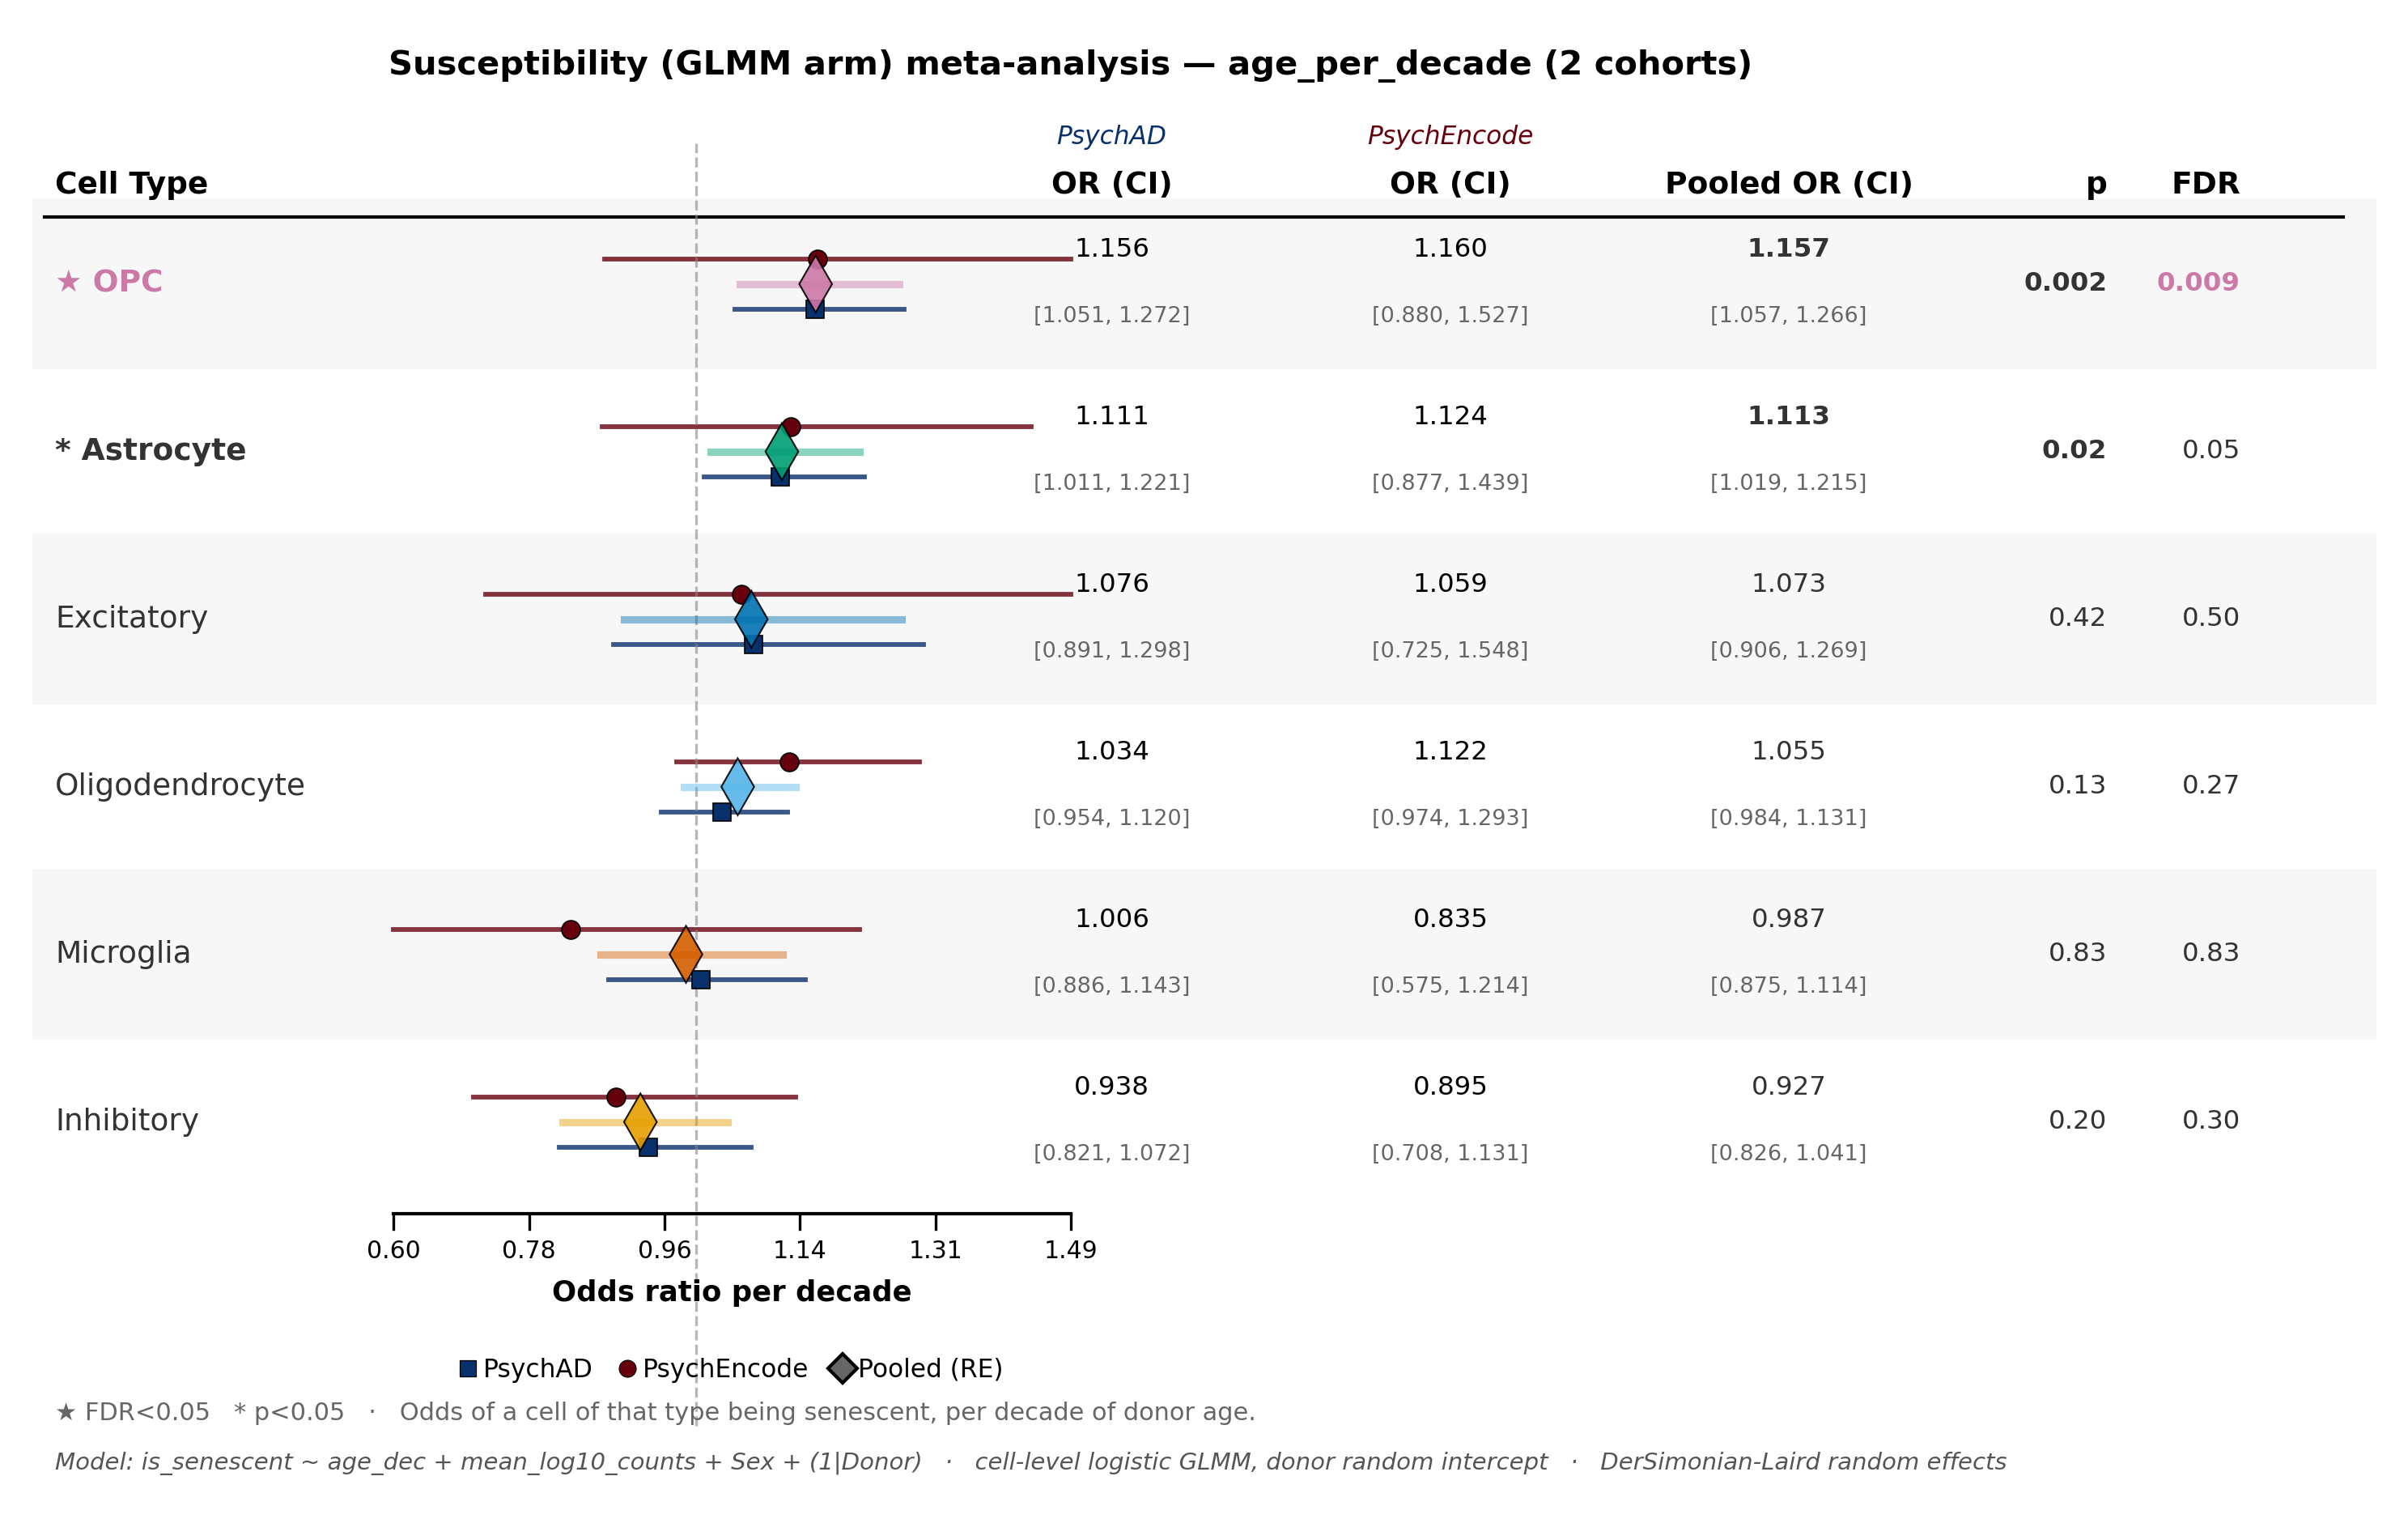

In [6]:
META_PATH = 'results/fig1F_source_data.csv'

ARM = dict(
    title="Susceptibility (GLMM arm)",
    xlabel="Odds ratio per decade",
    formula="is_senescent ~ age_dec + mean_log10_counts + Sex + (1|Donor)",
    method="cell-level logistic GLMM, donor random intercept",
    note="Odds of a cell of that type being senescent, per decade of donor age.",
)
CONTRAST  = "age_per_decade"
FDR_LEVEL = 0.05
MAJOR_CTS = ["OPC", "Astrocyte", "Excitatory",
             "Oligodendrocyte", "Microglia", "Inhibitory"]
COHORT_MARK = {"PsychAD": "s", "PsychEncode": "o", "PsychENCODE": "o", "Mathys": "o"}

import ast, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

def fmt_b(v):
    return f"{v:.3f}"

def fmt_ci(lo, hi):
    return f"[{lo:.3f}, {hi:.3f}]"

def fmt_tick(v):
    return f"{v:.2f}"

def fmt_p(v):
    return f"{v:.1e}" if v < 0.001 else (f"{v:.3f}" if v < 0.01 else f"{v:.2f}")

meta = pd.read_csv(META_PATH)
as_list = lambda v: v if isinstance(v, (list, tuple, np.ndarray)) else ast.literal_eval(str(v))
for c in ("cohort_names", "cohort_betas", "cohort_ses"):
    meta[c] = meta[c].map(as_list)
if 'pooled_or' not in meta.columns:
    meta['pooled_or']   = np.exp(meta['pooled_beta'])
    meta['ci_lower_or'] = np.exp(meta['ci_lo'])
    meta['ci_upper_or'] = np.exp(meta['ci_hi'])
    print("derived pooled_or, ci_lower_or, ci_upper_or from the beta columns")
meta = meta[meta.Cell_Type.isin(MAJOR_CTS)]
meta = (meta.assign(_o=meta.Cell_Type.map({c: i for i, c in enumerate(MAJOR_CTS)}))
            .sort_values("_o").drop(columns="_o").reset_index(drop=True))

names = list(dict.fromkeys(n for r in meta.cohort_names for n in r))
n = len(meta)

x = {"ct": 0.005, "fL": 0.17, "fR": 0.50}
for i, nm in enumerate(names): x[nm] = 0.52 + i * 0.165
b0 = 0.52 + len(names) * 0.165
cols = [("pooled", b0, "center"), ("p", b0 + 0.155, "right"),
        ("fdr", b0 + 0.220, "right")]
x.update({k: v for k, v, _ in cols})
heads = {"pooled": "Pooled OR (CI)", "p": "p", "fdr": "FDR"}

vals = ([np.exp(v) for _, r in meta.iterrows() for v in r.cohort_betas]
        + list(meta.ci_lower_or) + list(meta.ci_upper_or))
lo, hi = min(vals), max(vals)
pad = max((hi - lo) * 0.5, 1e-7); lo, hi = lo - pad, hi + pad
to_x = lambda v: x["fL"] + (np.clip(v, lo, hi) - lo) / (hi - lo) * (x["fR"] - x["fL"])
off = [-0.15, 0.15] if len(names) == 2 else list(np.linspace(-0.18, 0.18, len(names)))

fig = plt.figure(figsize=(10.2, max(3.4, n * 0.64 + 2.6)))
ax = fig.add_subplot(111)
y_hdr, y_lbl = n - 0.5, n - 0.2

for nm in names:
    ax.text(x[nm], y_lbl, nm, fontsize=7.5, style="italic",
            color=color_for('cohort', [nm])[0], ha="center", va="bottom")
    ax.text(x[nm], y_hdr, "OR (CI)", fontsize=9, fontweight="bold",
            ha="center", va="bottom")
ax.text(x["ct"], y_hdr, "Cell Type", fontsize=9, fontweight="bold", ha="left", va="bottom")
for key, xx, align in cols:
    ax.text(xx, y_hdr, heads[key], fontsize=9, fontweight="bold", ha=align, va="bottom")
ax.plot([0, 1.12], [y_hdr - 0.10, y_hdr - 0.10], "k-", lw=1, clip_on=False)

for i, r in meta.iterrows():
    yy = n - i - 1
    if i % 2 == 0:
        ax.axhspan(yy - 0.5, yy + 0.5, xmin=0.004, xmax=0.996, color="#f7f7f7", zorder=0)
    c = color_for('cell_type', [r.Cell_Type])[0]
    sig, sigp = bool(r.Significant), r.p < 0.05
    ax.text(x["ct"], yy, ("★ " if sig else "* " if sigp else "") + r.Cell_Type,
            fontsize=9, fontweight="bold" if sigp else "normal",
            ha="left", va="center", color=c if sig else "#333")

    for j, (nm, bb, se) in enumerate(zip(r.cohort_names, r.cohort_betas, r.cohort_ses)):
        yo = yy + off[j]; cc = color_for('cohort', [nm])[0]
        ax.plot([to_x(np.exp(bb - 1.96 * se)), to_x(np.exp(bb + 1.96 * se))], [yo, yo],
                color=cc, lw=1.4, alpha=0.8, zorder=2)
        ax.plot(to_x(np.exp(bb)), yo, COHORT_MARK.get(nm, "o"), ms=5.5,
                color=cc, mec="black", mew=0.4, zorder=3)
        ax.text(x[nm], yy + 0.13, fmt_b(np.exp(bb)), fontsize=7.8, ha="center", va="bottom")
        ax.text(x[nm], yy - 0.13, fmt_ci(np.exp(bb - 1.96 * se), np.exp(bb + 1.96 * se)),
                fontsize=6.5, ha="center", va="top", color="#666")

    xr = to_x(r.pooled_or)
    ax.plot([to_x(r.ci_lower_or), to_x(r.ci_upper_or)], [yy, yy],
            color=c, lw=2.2, alpha=0.45, zorder=4)
    ax.add_patch(Polygon([[xr - 0.008, yy], [xr, yy - 0.17], [xr + 0.008, yy],
                          [xr, yy + 0.17]], fc=c, ec="black", lw=0.5, zorder=5, alpha=0.9))

    cell = {"pooled": (fmt_b(r.pooled_or), fmt_ci(r.ci_lower_or, r.ci_upper_or)),
            "p": (fmt_p(r.p), None), "fdr": (fmt_p(r.p_adj), None)}
    for key, xx, align in cols:
        top, bot = cell[key]
        fw = "bold" if (sig if key == "fdr" else sigp) else "normal"
        col = c if (key == "fdr" and sig) else "#333"
        ax.text(xx, yy + (0.13 if bot else 0), top, fontsize=7.8, ha=align,
                va="bottom" if bot else "center", fontweight=fw, color=col)
        if bot:
            ax.text(xx, yy - 0.13, bot, fontsize=6.5, ha=align, va="top", color="#666")

ya = -0.55
ax.plot([x["fL"], x["fR"]], [ya, ya], "k-", lw=1)
ax.axvline(to_x(1.0), color="#888", ls="--", lw=0.8, ymin=0.06, ymax=0.92, alpha=0.6)
for t in np.linspace(lo, hi, 6):
    ax.plot([to_x(t)] * 2, [ya, ya - 0.09], "k-", lw=0.8)
    ax.text(to_x(t), ya - 0.15, fmt_tick(t), fontsize=7.2, ha="center", va="top")
ax.text((x["fL"] + x["fR"]) / 2, ya - 0.52, ARM["xlabel"],
        fontsize=8.5, fontweight="bold", ha="center")

leg = [Line2D([0], [0], marker=COHORT_MARK.get(nm, "o"), color="w",
              markerfacecolor=color_for('cohort', [nm])[0], markersize=5,
              markeredgecolor="black", markeredgewidth=0.3, label=nm) for nm in names]
leg.append(Line2D([0], [0], marker="D", color="w", markerfacecolor="#666",
                  markersize=6, markeredgecolor="black", label="Pooled (RE)"))
ax.legend(handles=leg, loc="upper center",
          bbox_to_anchor=((x["fL"] + x["fR"]) / 2, ya - 0.72),
          bbox_transform=ax.transData, fontsize=7.5, frameon=False,
          ncol=len(leg), handletextpad=0.35, columnspacing=1.1)

ax.text(0.5, y_lbl + 0.45,
        f"{ARM['title']} meta-analysis — {CONTRAST} ({len(names)} cohorts)",
        fontsize=10, fontweight="bold", ha="center")
ax.text(0.005, ya - 1.12,
        f"★ FDR<{FDR_LEVEL}   * p<0.05   ·   {ARM['note']}",
        fontsize=7.3, ha="left", va="top", color="#666")
ax.text(0.005, ya - 1.42,
        f"Model: {ARM['formula']}   ·   {ARM['method']}   ·   "
        f"DerSimonian-Laird random effects",
        fontsize=7.0, ha="left", va="top", color="#555", style="italic")

ax.set_xlim(-0.01, 1.14); ax.set_ylim(-2.35, y_lbl + 0.75); ax.axis("off")
plt.tight_layout()
plt.show()

# Figure 1G

derived pooled_or, ci_lower_or, ci_upper_or from the beta columns


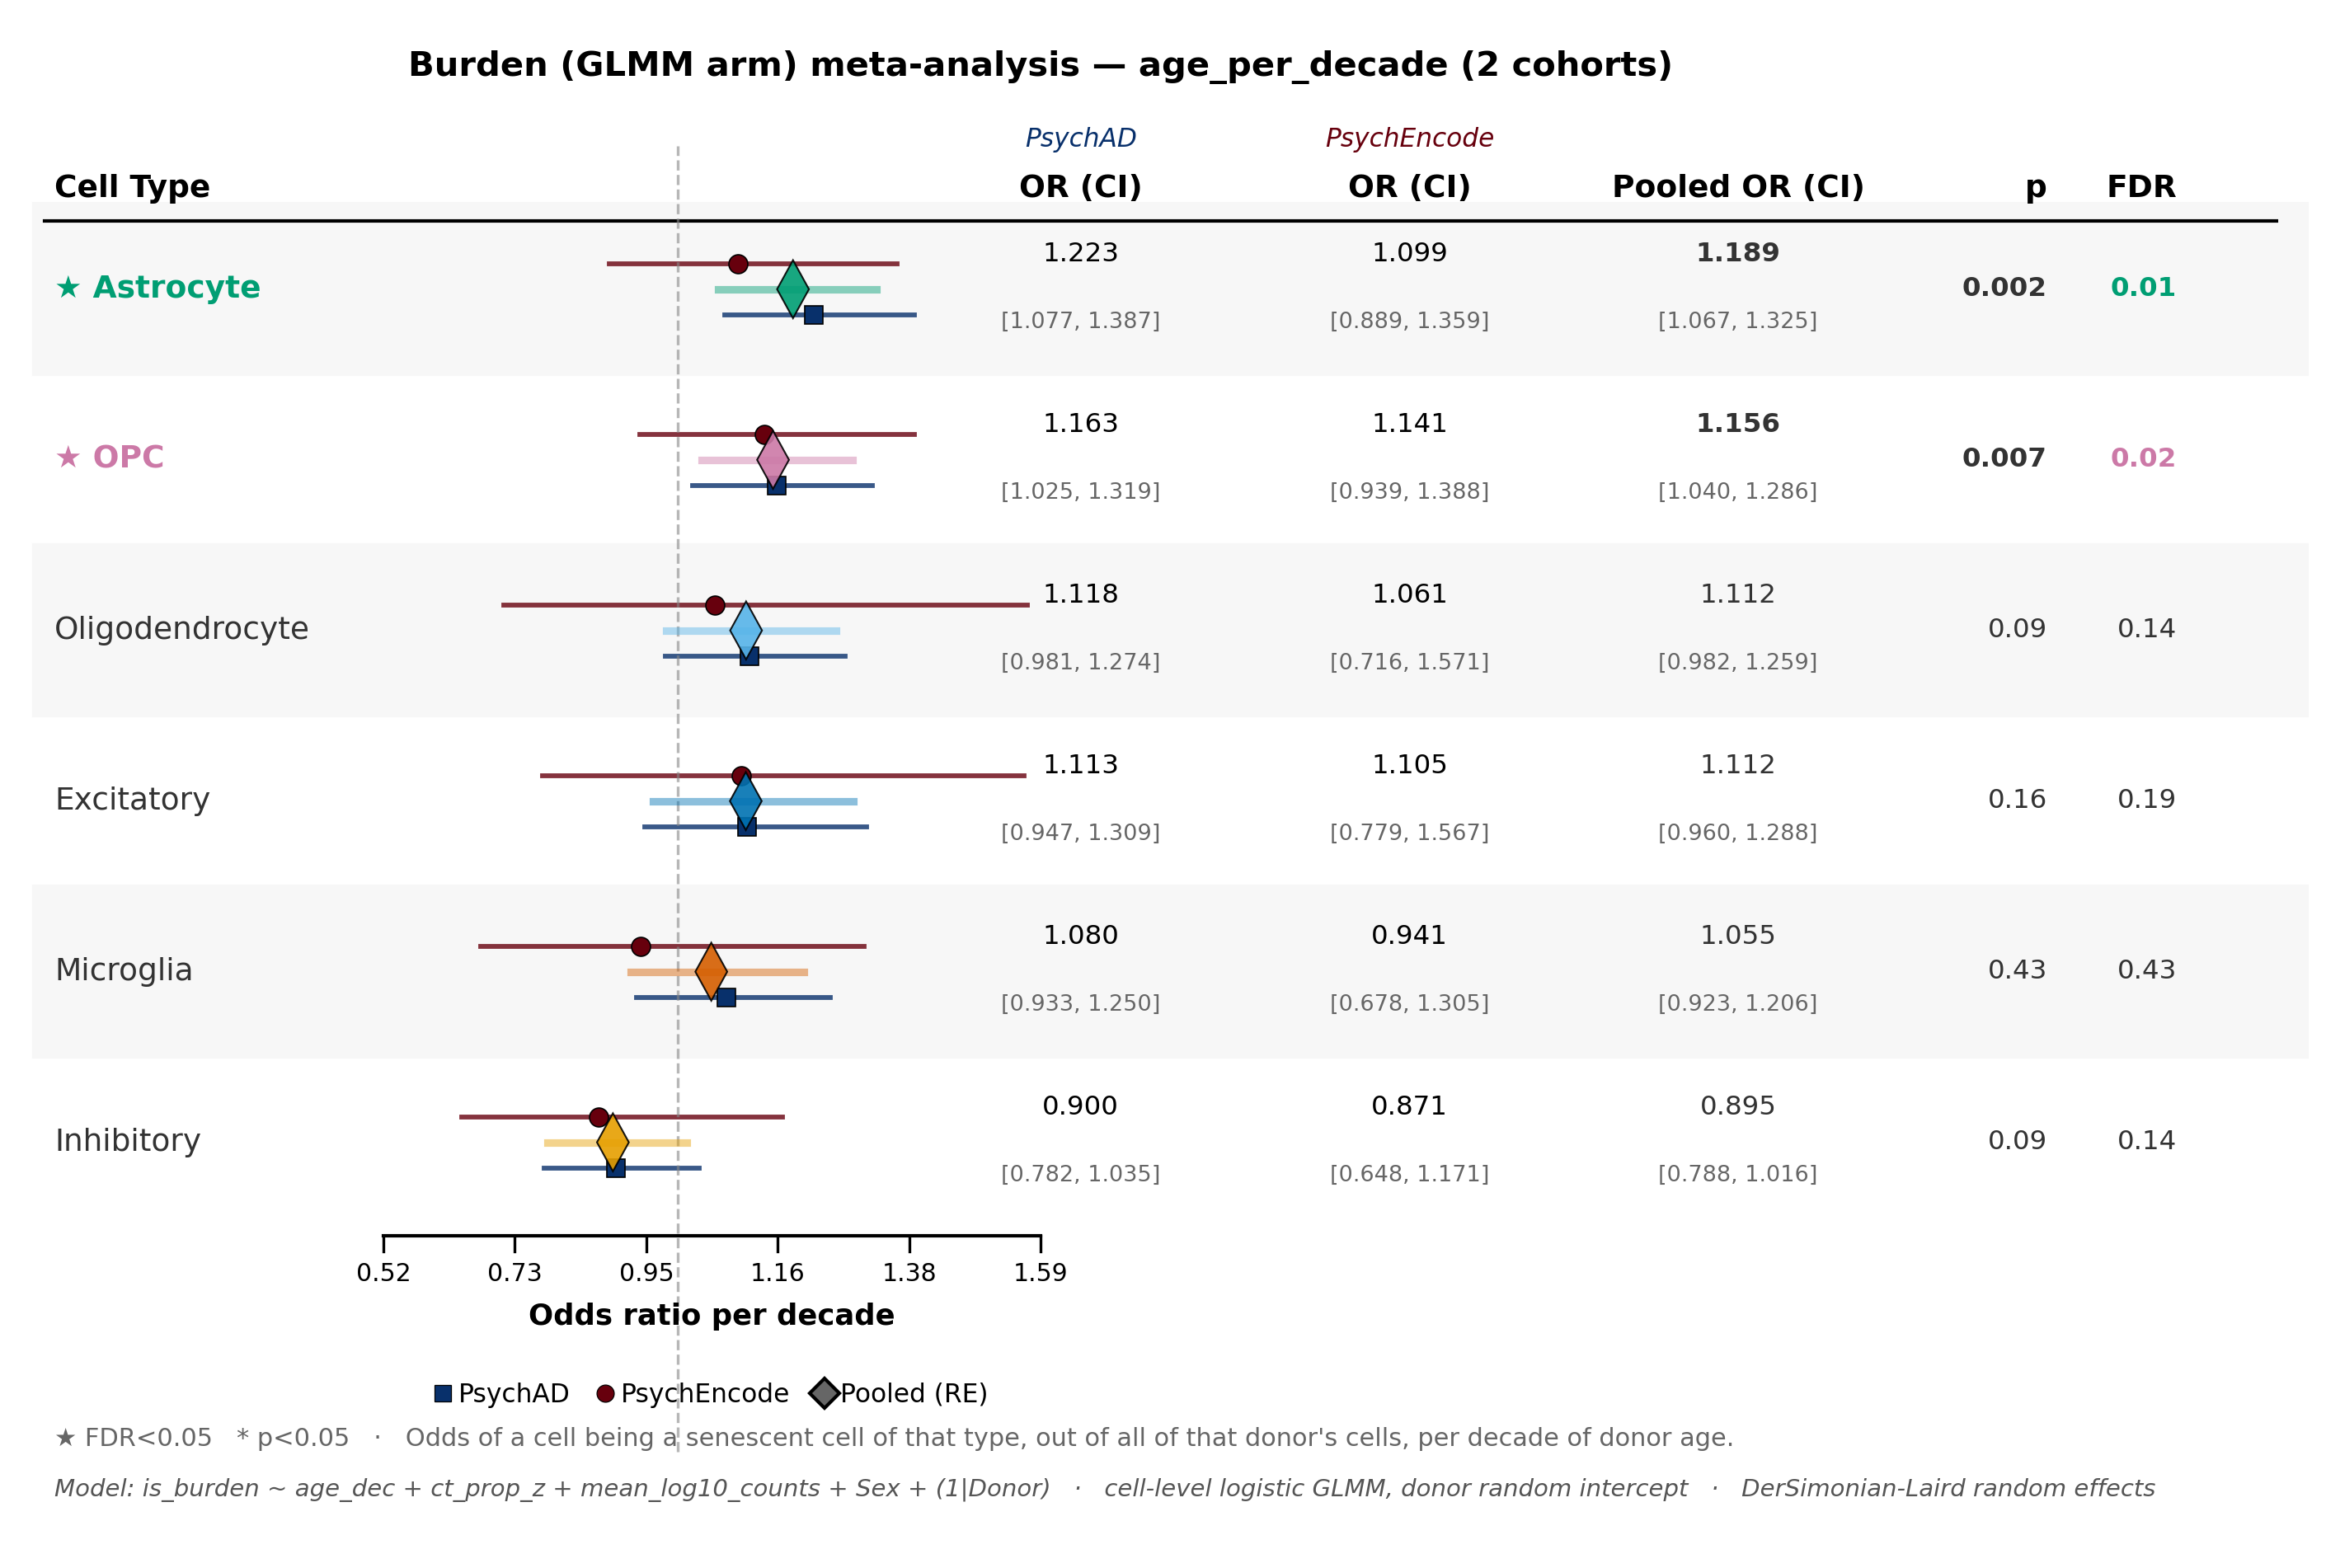

In [7]:
META_PATH = 'results/fig1G_source_data.csv'

ARM = dict(
    title="Burden (GLMM arm)",
    xlabel="Odds ratio per decade",
    formula="is_burden ~ age_dec + ct_prop_z + mean_log10_counts + Sex + (1|Donor)",
    method="cell-level logistic GLMM, donor random intercept",
    note="Odds of a cell being a senescent cell of that type, out of all of that "
         "donor's cells, per decade of donor age.",
)


CONTRAST  = "age_per_decade"
FDR_LEVEL = 0.05
MAJOR_CTS = ["Astrocyte", "OPC", "Oligodendrocyte", "Excitatory",
              "Microglia", "Inhibitory"]
COHORT_MARK = {"PsychAD": "s", "PsychEncode": "o", "PsychENCODE": "o", "Mathys": "o"}

import ast, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

def fmt_b(v):
    return f"{v:.3f}"

def fmt_ci(lo, hi):
    return f"[{lo:.3f}, {hi:.3f}]"

def fmt_tick(v):
    return f"{v:.2f}"

def fmt_p(v):
    return f"{v:.1e}" if v < 0.001 else (f"{v:.3f}" if v < 0.01 else f"{v:.2f}")

meta = pd.read_csv(META_PATH)
as_list = lambda v: v if isinstance(v, (list, tuple, np.ndarray)) else ast.literal_eval(str(v))
for c in ("cohort_names", "cohort_betas", "cohort_ses"):
    meta[c] = meta[c].map(as_list)
if 'pooled_or' not in meta.columns:
    meta['pooled_or']   = np.exp(meta['pooled_beta'])
    meta['ci_lower_or'] = np.exp(meta['ci_lo'])
    meta['ci_upper_or'] = np.exp(meta['ci_hi'])
    print("derived pooled_or, ci_lower_or, ci_upper_or from the beta columns")
meta = meta[meta.Cell_Type.isin(MAJOR_CTS)]
meta = (meta.assign(_o=meta.Cell_Type.map({c: i for i, c in enumerate(MAJOR_CTS)}))
            .sort_values("_o").drop(columns="_o").reset_index(drop=True))

names = list(dict.fromkeys(n for r in meta.cohort_names for n in r))
n = len(meta)

x = {"ct": 0.005, "fL": 0.17, "fR": 0.50}
for i, nm in enumerate(names): x[nm] = 0.52 + i * 0.165
b0 = 0.52 + len(names) * 0.165
cols = [("pooled", b0, "center"), ("p", b0 + 0.155, "right"),
        ("fdr", b0 + 0.220, "right")]
x.update({k: v for k, v, _ in cols})
heads = {"pooled": "Pooled OR (CI)", "p": "p", "fdr": "FDR"}

vals = ([np.exp(v) for _, r in meta.iterrows() for v in r.cohort_betas]
        + list(meta.ci_lower_or) + list(meta.ci_upper_or))
lo, hi = min(vals), max(vals)
pad = max((hi - lo) * 0.5, 1e-7); lo, hi = lo - pad, hi + pad
to_x = lambda v: x["fL"] + (np.clip(v, lo, hi) - lo) / (hi - lo) * (x["fR"] - x["fL"])
off = [-0.15, 0.15] if len(names) == 2 else list(np.linspace(-0.18, 0.18, len(names)))

fig = plt.figure(figsize=(10.2, max(3.4, n * 0.64 + 2.6)))
ax = fig.add_subplot(111)
y_hdr, y_lbl = n - 0.5, n - 0.2

for nm in names:
    ax.text(x[nm], y_lbl, nm, fontsize=7.5, style="italic",
            color=color_for('cohort', [nm])[0], ha="center", va="bottom")
    ax.text(x[nm], y_hdr, "OR (CI)", fontsize=9, fontweight="bold",
            ha="center", va="bottom")
ax.text(x["ct"], y_hdr, "Cell Type", fontsize=9, fontweight="bold", ha="left", va="bottom")
for key, xx, align in cols:
    ax.text(xx, y_hdr, heads[key], fontsize=9, fontweight="bold", ha=align, va="bottom")
ax.plot([0, 1.12], [y_hdr - 0.10, y_hdr - 0.10], "k-", lw=1, clip_on=False)

for i, r in meta.iterrows():
    yy = n - i - 1
    if i % 2 == 0:
        ax.axhspan(yy - 0.5, yy + 0.5, xmin=0.004, xmax=0.996, color="#f7f7f7", zorder=0)
    c = color_for('cell_type', [r.Cell_Type])[0]
    sig, sigp = bool(r.Significant), r.p < 0.05
    ax.text(x["ct"], yy, ("★ " if sig else "* " if sigp else "") + r.Cell_Type,
            fontsize=9, fontweight="bold" if sigp else "normal",
            ha="left", va="center", color=c if sig else "#333")

    for j, (nm, bb, se) in enumerate(zip(r.cohort_names, r.cohort_betas, r.cohort_ses)):
        yo = yy + off[j]; cc = color_for('cohort', [nm])[0]
        ax.plot([to_x(np.exp(bb - 1.96 * se)), to_x(np.exp(bb + 1.96 * se))], [yo, yo],
                color=cc, lw=1.4, alpha=0.8, zorder=2)
        ax.plot(to_x(np.exp(bb)), yo, COHORT_MARK.get(nm, "o"), ms=5.5,
                color=cc, mec="black", mew=0.4, zorder=3)
        ax.text(x[nm], yy + 0.13, fmt_b(np.exp(bb)), fontsize=7.8, ha="center", va="bottom")
        ax.text(x[nm], yy - 0.13, fmt_ci(np.exp(bb - 1.96 * se), np.exp(bb + 1.96 * se)),
                fontsize=6.5, ha="center", va="top", color="#666")

    xr = to_x(r.pooled_or)
    ax.plot([to_x(r.ci_lower_or), to_x(r.ci_upper_or)], [yy, yy],
            color=c, lw=2.2, alpha=0.45, zorder=4)
    ax.add_patch(Polygon([[xr - 0.008, yy], [xr, yy - 0.17], [xr + 0.008, yy],
                          [xr, yy + 0.17]], fc=c, ec="black", lw=0.5, zorder=5, alpha=0.9))

    cell = {"pooled": (fmt_b(r.pooled_or), fmt_ci(r.ci_lower_or, r.ci_upper_or)),
            "p": (fmt_p(r.p), None), "fdr": (fmt_p(r.p_adj), None)}
    for key, xx, align in cols:
        top, bot = cell[key]
        fw = "bold" if (sig if key == "fdr" else sigp) else "normal"
        col = c if (key == "fdr" and sig) else "#333"
        ax.text(xx, yy + (0.13 if bot else 0), top, fontsize=7.8, ha=align,
                va="bottom" if bot else "center", fontweight=fw, color=col)
        if bot:
            ax.text(xx, yy - 0.13, bot, fontsize=6.5, ha=align, va="top", color="#666")

ya = -0.55
ax.plot([x["fL"], x["fR"]], [ya, ya], "k-", lw=1)
ax.axvline(to_x(1.0), color="#888", ls="--", lw=0.8, ymin=0.06, ymax=0.92, alpha=0.6)
for t in np.linspace(lo, hi, 6):
    ax.plot([to_x(t)] * 2, [ya, ya - 0.09], "k-", lw=0.8)
    ax.text(to_x(t), ya - 0.15, fmt_tick(t), fontsize=7.2, ha="center", va="top")
ax.text((x["fL"] + x["fR"]) / 2, ya - 0.52, ARM["xlabel"],
        fontsize=8.5, fontweight="bold", ha="center")

leg = [Line2D([0], [0], marker=COHORT_MARK.get(nm, "o"), color="w",
              markerfacecolor=color_for('cohort', [nm])[0], markersize=5,
              markeredgecolor="black", markeredgewidth=0.3, label=nm) for nm in names]
leg.append(Line2D([0], [0], marker="D", color="w", markerfacecolor="#666",
                  markersize=6, markeredgecolor="black", label="Pooled (RE)"))
ax.legend(handles=leg, loc="upper center",
          bbox_to_anchor=((x["fL"] + x["fR"]) / 2, ya - 0.72),
          bbox_transform=ax.transData, fontsize=7.5, frameon=False,
          ncol=len(leg), handletextpad=0.35, columnspacing=1.1)

ax.text(0.5, y_lbl + 0.45,
        f"{ARM['title']} meta-analysis — {CONTRAST} ({len(names)} cohorts)",
        fontsize=10, fontweight="bold", ha="center")
ax.text(0.005, ya - 1.12,
        f"★ FDR<{FDR_LEVEL}   * p<0.05   ·   {ARM['note']}",
        fontsize=7.3, ha="left", va="top", color="#666")
ax.text(0.005, ya - 1.42,
        f"Model: {ARM['formula']}   ·   {ARM['method']}   ·   "
        f"DerSimonian-Laird random effects",
        fontsize=7.0, ha="left", va="top", color="#555", style="italic")

ax.set_xlim(-0.01, 1.14); ax.set_ylim(-2.35, y_lbl + 0.75); ax.axis("off")
plt.tight_layout()
plt.show()

# Figure 1H

Fig1H colors: {'Excitatory': '#0072B2', 'Inhibitory': '#E69F00', 'Astrocyte': '#009E73', 'Oligodendrocyte': '#56B4E9', 'Microglia': '#D55E00', 'OPC': '#CC79A7'}


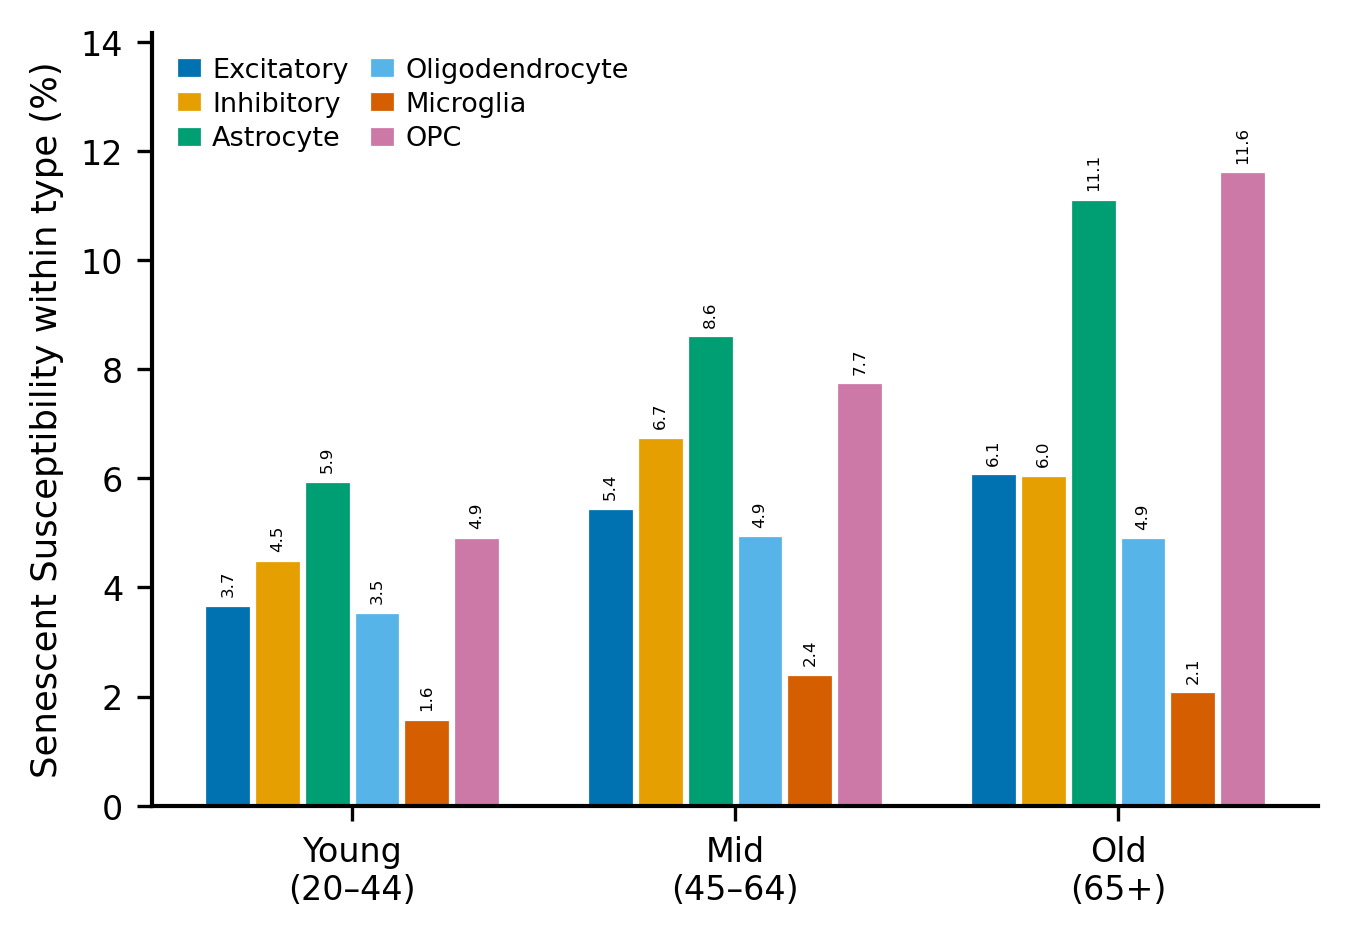

In [8]:
SRC         = 'results/fig1H&I_source_data.csv'
AGE_ORDER   = ['Young', 'Mid', 'Old']
AGE_LABEL   = {'Young': 'Young\n(20–44)', 'Mid': 'Mid\n(45–64)', 'Old': 'Old\n(65+)'}
CELL_ORDER  = ['Excitatory', 'Inhibitory', 'Astrocyte', 'Oligodendrocyte', 'Microglia', 'OPC']
ARROWS      = {}      # {'Astrocyte': (beta, padj), ...} from the AgeGrp-factor GLMM, Old vs Young
BAR_LABELS  = True

import numpy as np, pandas as pd, matplotlib.pyplot as plt

d = pd.read_csv(SRC)
d.columns = [c.strip() for c in d.columns]
d = d.loc[:, ~d.columns.str.match(r'^Unnamed')]

h = d.pivot(index='AgeGrp', columns='Cell_Type', values='Susceptibility_%')
miss = [c for c in CELL_ORDER if c not in h.columns] + [g for g in AGE_ORDER if g not in h.index]
if miss:
    raise ValueError(f"not in file: {miss}")
h = h.reindex(index=AGE_ORDER, columns=CELL_ORDER)

ct_hex = color_for('cell_type', CELL_ORDER)
print("Fig1H colors:", dict(zip(CELL_ORDER, ct_hex)))

n_ct = len(CELL_ORDER)
x    = np.arange(len(AGE_ORDER))
w    = 0.78 / n_ct
ymax = float(np.nanmax(h.values))

fig, ax = plt.subplots(figsize=(4.6, 3.2))
for k, ct in enumerate(CELL_ORDER):
    xx   = x + (k - (n_ct - 1) / 2) * w
    v    = h[ct].values
    bars = ax.bar(xx, v, width=w * 0.9, color=ct_hex[k],
                  edgecolor='white', linewidth=0.3, label=ct, zorder=2)
    if BAR_LABELS:
        for bar, val in zip(bars, v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ymax * 0.015,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=4, rotation=90)
    beta, padj = ARROWS.get(ct, (0.0, 1.0))
    if padj < 0.05:
        j = AGE_ORDER.index('Old')
        ax.text(xx[j], v[j] + ymax * 0.09, '▲' if beta >= 0 else '▼',
                ha='center', va='bottom', fontsize=6, color=ct_hex[k],
                fontweight='bold', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([AGE_LABEL.get(g, g) for g in AGE_ORDER], fontsize=8)
ax.set_ylabel('Senescent Susceptibility within type (%)', fontsize=8.5)
ax.set_ylim(0, ymax * 1.22)
ax.tick_params(labelsize=8)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.legend(fontsize=6.5, frameon=False, ncol=2, loc='upper left',
          handlelength=0.9, handletextpad=0.4, columnspacing=0.8, labelspacing=0.3)
fig.tight_layout()
plt.show()

# Figure 1I

group total senescent (% of all cells): {'Young': 4.078, 'Mid': 5.53, 'Old': 6.461}
Fig1I colors: {'Excitatory': '#0072B2', 'Inhibitory': '#E69F00', 'Astrocyte': '#009E73', 'Oligodendrocyte': '#56B4E9', 'Microglia': '#D55E00', 'OPC': '#CC79A7'}


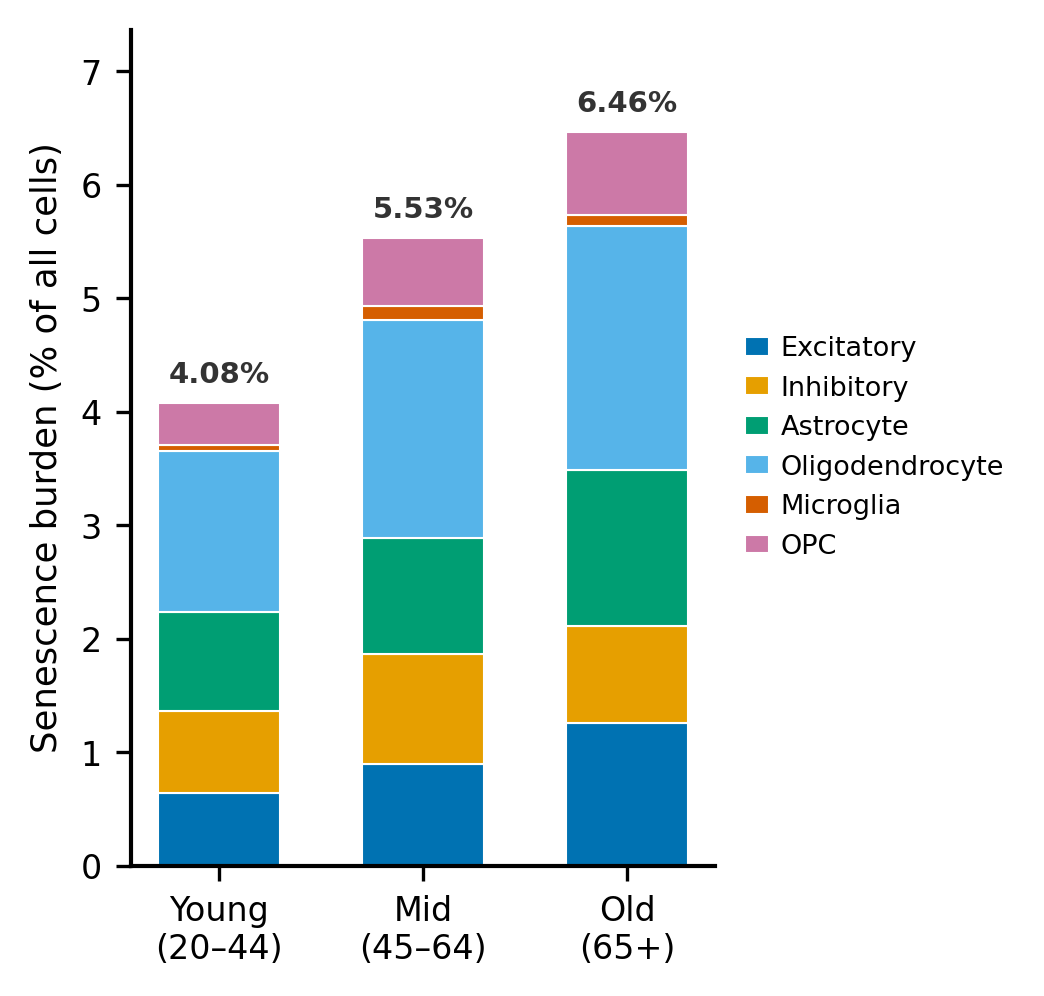

In [9]:
SRC        = 'results/fig1H&I_source_data.csv'
AGE_ORDER  = ['Young', 'Mid', 'Old']
AGE_LABEL  = {'Young': 'Young\n(20–44)', 'Mid': 'Mid\n(45–64)', 'Old': 'Old\n(65+)'}
CELL_ORDER = ['Excitatory', 'Inhibitory', 'Astrocyte', 'Oligodendrocyte', 'Microglia', 'OPC']
NORMALIZE  = False    
ARROWS     = {}
LABEL_MIN  = 0.06

d = pd.read_csv(SRC)
d.columns = [c.strip() for c in d.columns]
d = d.loc[:, ~d.columns.str.match(r'^Unnamed')]

b = d.pivot(index='AgeGrp', columns='Cell_Type', values='Burden_%')
miss = [c for c in CELL_ORDER if c not in b.columns] + [g for g in AGE_ORDER if g not in b.index]
if miss:
    raise ValueError(f"not in file: {miss}")
b = b.reindex(index=AGE_ORDER, columns=CELL_ORDER)

totals = b.sum(axis=1)
print("group total senescent (% of all cells):", totals.round(3).to_dict())
if NORMALIZE:
    b = b.div(totals, axis=0) * 100
    ylab, lmin = 'Contribution to senescent pool (%)', 3.0
else:
    ylab, lmin = 'Senescence burden (% of all cells)', LABEL_MIN

ct_hex = color_for('cell_type', CELL_ORDER)
print("Fig1I colors:", dict(zip(CELL_ORDER, ct_hex)))

x, bottom = np.arange(len(AGE_ORDER)), np.zeros(len(AGE_ORDER))
top = float(b.sum(axis=1).max())

fig, ax = plt.subplots(figsize=(3.6, 3.4))
for k, ct in enumerate(CELL_ORDER):
    v = b[ct].values
    ax.bar(x, v, bottom=bottom, width=0.6, color=ct_hex[k],
           edgecolor='white', linewidth=0.5, label=ct, zorder=2)
    beta, padj = ARROWS.get(ct, (0.0, 1.0))
    j = AGE_ORDER.index('Old')
    if padj < 0.05 and v[j] >= lmin:
        ax.text(x[j], bottom[j] + v[j] / 2, '▲' if beta >= 0 else '▼',
                ha='center', va='center', fontsize=6, color='white',
                fontweight='bold', zorder=5)
    bottom = bottom + v

if NORMALIZE:
    ax.set_ylim(0, 100); ax.set_yticks([0, 25, 50, 75, 100])
else:
    for xi, t in zip(x, totals.values):
        ax.text(xi, t + top * 0.02, f'{t:.2f}%', ha='center', va='bottom',
                fontsize=7, fontweight='bold', color='#333')
    ax.set_ylim(0, top * 1.14)

ax.set_xticks(x)
ax.set_xticklabels([AGE_LABEL.get(g, g) for g in AGE_ORDER], fontsize=8)
ax.set_ylabel(ylab, fontsize=8.5)
ax.tick_params(labelsize=8)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.legend(fontsize=6.5, frameon=False, loc='center left',
          bbox_to_anchor=(1.01, 0.5), handlelength=0.9, handletextpad=0.4)
fig.tight_layout()
plt.show()